The bound determined in class was: ebound <= 0.25 for the function f(x) = sin(pi * x / 2)
- the lagrange function is P(x) = 2x - x^2

[0.0, 1.0, 2.0] [0.0, 1.0, 1.2246467991473532e-16]


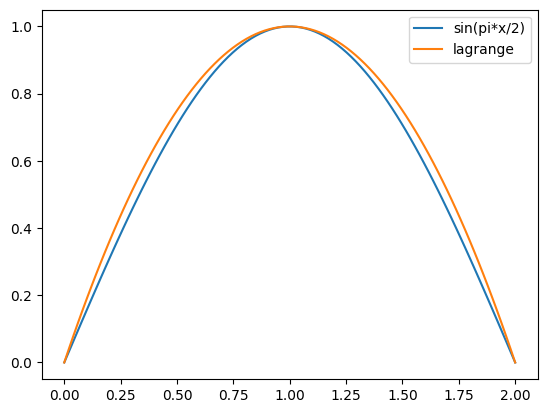

the max error is: 0.05600671977855842


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def givenfunc(x):
    return np.sin((np.pi * x) / 2)

def lagrangefun(x):
    return 2*x - (x**2)

xi = np.array([0, 1, 2], dtype=float)
fi = givenfunc(xi)
print(xi.tolist(), fi.tolist())

t = np.linspace(0, 2, 100)
plt.plot(t, givenfunc(t), label='sin(pi*x/2)')
plt.plot(t, lagrangefun(t), label='lagrange')
plt.legend()
plt.show()


print("the max error is:", max(abs(lagrangefun(t)-givenfunc(t))))

can the bound be infinity?

Newtons divided difference

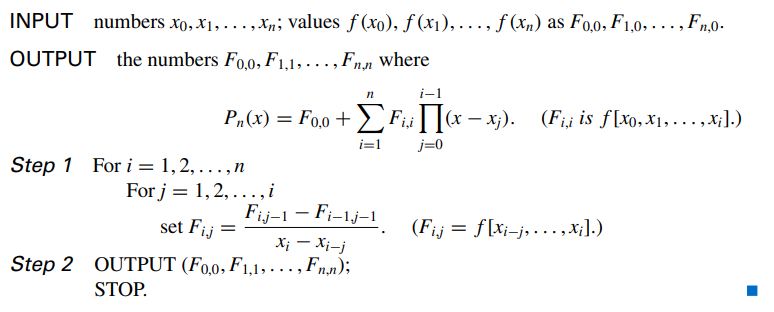

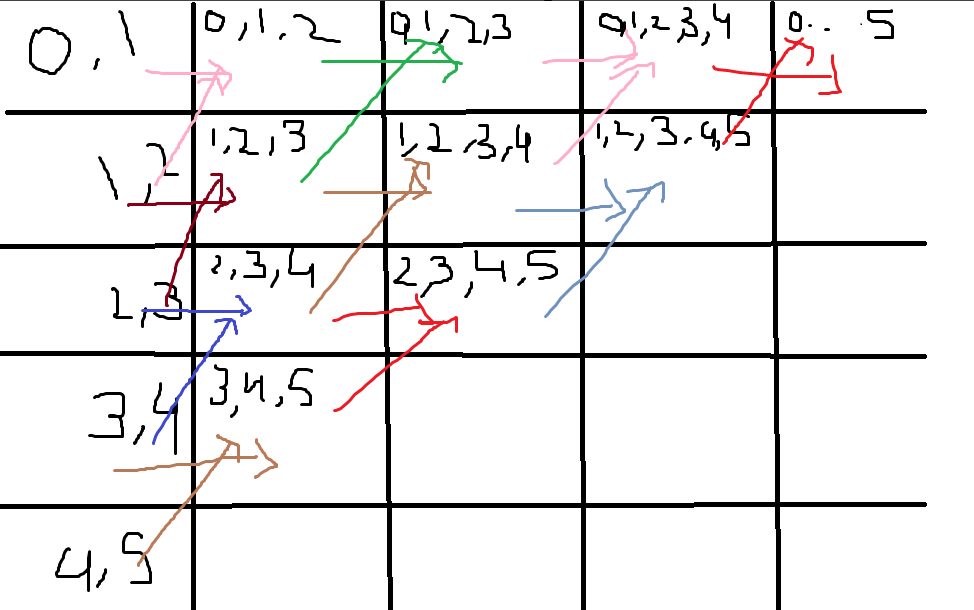

[[1.         0.         0.         0.         0.        ]
 [1.2214     1.107      0.         0.         0.        ]
 [1.49182    1.3521     0.61275    0.         0.        ]
 [1.82212    1.6515     0.7485     0.22625    0.        ]
 [2.22554    2.0171     0.914      0.27583333 0.06197917]]


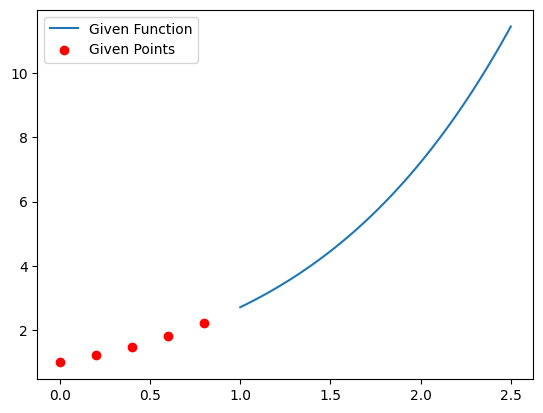

In [5]:
import numpy as np

def divideddifferencematrix(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    n = len(x) 
    F = np.zeros((n, n), dtype=float)
    F[:, 0] = y

    for i in range(1, n):
        for j in range(1, i + 1):
            F[i, j] = (F[i, j - 1] - F[i - 1, j - 1]) / (x[i] - x[i - j])

    return F

def divideddifference(x, y, X):
    F = divideddifferencematrix(x, y)
    result = F[0, 0]
    n = len(x)
    for i in range(1, n):
        product = 1
        for j in range(0, i):
            product *= (X - x[j])
        result += F[i, i] * product
    return result

x = [1, 1.3, 1.6, 1.9, 2.2]
y = [0.7651977, 0.6200860, 0.4554022, 0.2818186, 0.1103623]
x = [0, 0.2, 0.4, 0.6, 0.8]
y = [1, 1.22140, 1.49182, 1.82212, 2.22554]
F = divideddifferencematrix(x, y)
print(F)

t = np.linspace(1, 2.5, 100)
plt.plot(t, divideddifference(x,y,t), label='Given Function')
plt.scatter(x, y, color='red', label = 'Given Points')
plt.legend()
plt.show()


between any 2 sets of data, theres only one lagrange polynomial that can be formed.

NDD(x) = Lagrange(x)

Error can be done by splitting the dataset? train and test data

Compare with taylor series expansion


whats the root of the divided difference func

difference btw
- df/dx(x1) ~ (f(xi+1) - f(xi)) / (xi+1 - xi) :  forward difference
- df/dx(x1) ~ (f(xi) - f(xi-1)) / (xi - xi-1) :  backward difference
- whats central difference? df/dx(x1) ~ (f(xi+1) - f(xi-1)) / (xi+1 - xi-1)